In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



Load data

In [3]:
df = pd.read_csv('qsr_demand_dataset.csv')

Quick Data Quality Check

In [4]:
#Task 1 confirm shape of data and change some data types
print(df.shape)

print(df.dtypes)

df['date'] = pd.to_datetime(df['date'])

df.dtypes

(1369500, 23)
date                      str
restaurant_id             str
restaurant_name           str
city                      str
state                     str
menu_item_id              str
menu_item_name            str
category                  str
unit_price            float64
quantity              float64
day_of_week               str
day_of_week_num         int64
is_weekend              int64
month                   int64
year                    int64
avg_temp_f            float64
precip_inches         float64
precip_type               str
is_holiday              int64
holiday_name              str
is_special_event        int64
special_event_name        str
is_promotion            int64
dtype: object


date                  datetime64[us]
restaurant_id                    str
restaurant_name                  str
city                             str
state                            str
menu_item_id                     str
menu_item_name                   str
category                         str
unit_price                   float64
quantity                     float64
day_of_week                      str
day_of_week_num                int64
is_weekend                     int64
month                          int64
year                           int64
avg_temp_f                   float64
precip_inches                float64
precip_type                      str
is_holiday                     int64
holiday_name                     str
is_special_event               int64
special_event_name               str
is_promotion                   int64
dtype: object

In [5]:
print("\n" + "=" * 55)
print("TASK 2 — Missing quantity analysis")
print("=" * 55)

missing = df[df["quantity"].isna()].copy()
total_rows = len(df)
missing_rows = len(missing)

print(f"Total rows:    {total_rows:,}")
print(f"Missing rows:  {missing_rows:,}  ({missing_rows / total_rows * 100:.2f}% of data)")

print("\nMissing count by year:")
print(missing.groupby("year").size().to_string())

print("\nMissing count by restaurant:")
print(missing.groupby("restaurant_id").size().sort_values().to_string())

print("\nMissing count by menu item (top 20):")
print(missing.groupby("menu_item_id").size().sort_values(ascending=False).head(20).to_string())

# How many unique dates have at least one NaN per restaurant?
missing_dates_per_rest = missing.groupby("restaurant_id")["date"].nunique()
print("\nUnique dates with at least one NaN per restaurant:")
print(missing_dates_per_rest.to_string())

# Are multiple items missing on the same date at the same restaurant?
same_day_missing = (
    missing.groupby(["restaurant_id", "date"])
    .size()
    .rename("items_missing")
    .reset_index()
)
print("\nHow many items missing on same restaurant-date? (1 = truly random)")
print(same_day_missing["items_missing"].value_counts().sort_index().to_string())

print("\nConclusion: NaNs are randomly scattered individual item-level records.")
print("Recommendation for modeling: safe to drop these rows (~0.4% of data).")


TASK 2 — Missing quantity analysis
Total rows:    1,369,500
Missing rows:  5,475  (0.40% of data)

Missing count by year:
year
2021    1122
2022    1091
2023    1062
2024    1053
2025    1147

Missing count by restaurant:
restaurant_id
R01    365
R02    365
R03    365
R04    365
R05    365
R06    365
R07    365
R08    365
R09    365
R10    365
R11    365
R12    365
R13    365
R14    365
R15    365

Missing count by menu item (top 20):
menu_item_id
M06    133
M50    126
M44    126
M12    125
M42    123
M02    123
M47    122
M33    121
M43    121
M31    120
M09    119
M30    118
M05    117
M19    116
M37    115
M38    115
M39    115
M16    114
M35    113
M17    113

Unique dates with at least one NaN per restaurant:
restaurant_id
R01    329
R02    325
R03    330
R04    327
R05    331
R06    339
R07    334
R08    331
R09    334
R10    331
R11    331
R12    332
R13    333
R14    328
R15    334

How many items missing on same restaurant-date? (1 = truly random)
items_missing
1    4488
2   

In [6]:
print("\n" + "=" * 55)
print("TASK 3 — Sparse item/restaurant combos")
print("=" * 55)

coverage = (
    df[df["quantity"].notna()]
    .groupby(["restaurant_id", "menu_item_id"])["date"]
    .nunique()
    .rename("days_with_sales")
    .reset_index()
)

total_days = df["date"].nunique()
coverage["coverage_pct"] = (coverage["days_with_sales"] / total_days * 100).round(1)

print(f"Total calendar days in dataset: {total_days}")
print(f"Total combos (15 × 50): {len(coverage)}")
print(f"\nCoverage % stats across all combos:")
print(coverage["coverage_pct"].describe().round(1))

sparse = coverage[coverage["coverage_pct"] < 80].sort_values("coverage_pct")
print(f"\nSparse combos (< 80% coverage): {len(sparse)}")
if len(sparse) > 0:
    print(sparse.head(20).to_string(index=False))
else:
    print("None — all combos have >= 80% coverage. Clean dataset.")

zero_sales = (
    df[df["quantity"] == 0]
    .groupby(["restaurant_id", "menu_item_id"])
    .size()
    .rename("zero_days")
    .reset_index()
    .sort_values("zero_days", ascending=False)
)
print(f"\nCombos with most zero-sales days (top 15):")
print(zero_sales.head(15).to_string(index=False))


TASK 3 — Sparse item/restaurant combos
Total calendar days in dataset: 1826
Total combos (15 × 50): 750

Coverage % stats across all combos:
count    750.0
mean      99.6
std        0.1
min       99.1
25%       99.5
50%       99.6
75%       99.7
max       99.9
Name: coverage_pct, dtype: float64

Sparse combos (< 80% coverage): 0
None — all combos have >= 80% coverage. Clean dataset.

Combos with most zero-sales days (top 15):
restaurant_id menu_item_id  zero_days
          R03          M37        180
          R02          M37        175
          R03          M35        175
          R05          M40        173
          R07          M07        172
          R11          M08        168
          R12          M35        168
          R11          M37        167
          R09          M20        167
          R06          M33        167
          R11          M20        166
          R01          M36        165
          R10          M08        165
          R13          M22        164


TASK 4 — Outliers (quantity > 200)
Rows with quantity > 200: 473

Of outlier rows:
  Tied to special event:  18.4%
  Tied to promotion:      2.7%
  Tied to either:         20.1%

Unexplained outliers (no event, no promo): 378
      date restaurant_id menu_item_id  category  quantity                                    holiday_name
2021-03-25           R01          M16     Sides     261.0                                             NaN
2021-05-13           R01          M31 Breakfast     289.0                                             NaN
2021-05-23           R01          M01   Burgers     358.0                                             NaN
2021-05-30           R01          M43    Combos     279.0                                             NaN
2021-06-01           R01          M43    Combos     238.0                                             NaN
2021-06-08           R01          M45    Combos     211.0                                             NaN
2021-06-17           R01       

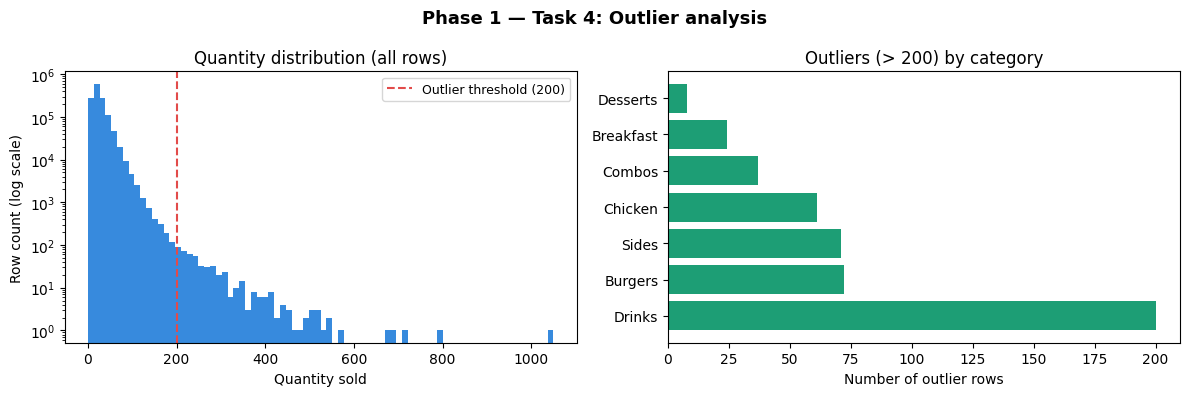

Saved: phase1_outliers.png


In [7]:
print("\n" + "=" * 55)
print("TASK 4 — Outliers (quantity > 200)")
print("=" * 55)

outliers = df[df["quantity"] > 200].copy()
print(f"Rows with quantity > 200: {len(outliers)}")

pct_event  = outliers["is_special_event"].mean() * 100
pct_promo  = outliers["is_promotion"].mean() * 100
pct_either = outliers[
    (outliers["is_special_event"] == 1) | (outliers["is_promotion"] == 1)
].shape[0] / len(outliers) * 100

print(f"\nOf outlier rows:")
print(f"  Tied to special event:  {pct_event:.1f}%")
print(f"  Tied to promotion:      {pct_promo:.1f}%")
print(f"  Tied to either:         {pct_either:.1f}%")

unexplained = outliers[
    (outliers["is_special_event"] == 0) & (outliers["is_promotion"] == 0)
]
print(f"\nUnexplained outliers (no event, no promo): {len(unexplained)}")
if len(unexplained) > 0:
    print(unexplained[["date", "restaurant_id", "menu_item_id",
                        "category", "quantity", "holiday_name"]].head(20).to_string(index=False))

print("\nOutlier count by category:")
print(outliers["category"].value_counts().to_string())

print(f"\nTop 10 highest quantity records:")
print(
    df.nlargest(10, "quantity")[
        ["date", "restaurant_id", "menu_item_id", "category",
         "quantity", "is_special_event", "is_promotion", "holiday_name"]
    ].to_string(index=False)
)

# ── Visualization ─────────────────────────────────────────
import matplotlib.ticker as mticker
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Phase 1 — Task 4: Outlier analysis", fontsize=13, fontweight="bold")

axes[0].hist(df["quantity"].dropna(), bins=80, color="#378ADD", edgecolor="none")
axes[0].axvline(200, color="#E24B4A", linewidth=1.5, linestyle="--", label="Outlier threshold (200)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Quantity sold")
axes[0].set_ylabel("Row count (log scale)")
axes[0].set_title("Quantity distribution (all rows)")
axes[0].legend(fontsize=9)

cat_counts = outliers["category"].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color="#1D9E75")
axes[1].set_xlabel("Number of outlier rows")
axes[1].set_title("Outliers (> 200) by category")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("phase1_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase1_outliers.png")

Seasonality and Trends

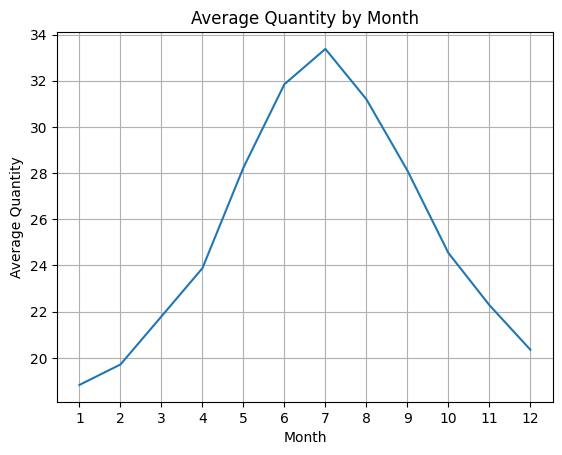

In [8]:
monthly_avg_quantity = df.groupby('month')['quantity'].mean()
monthly_avg_quantity.plot(kind='line', title='Average Quantity by Month')
plt.xlabel('Month')
plt.ylabel('Average Quantity')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### Seasonality by Category
Let's investigate if seasonality differs across categories, specifically for 'Breakfast', 'Drinks', and 'Burgers'.

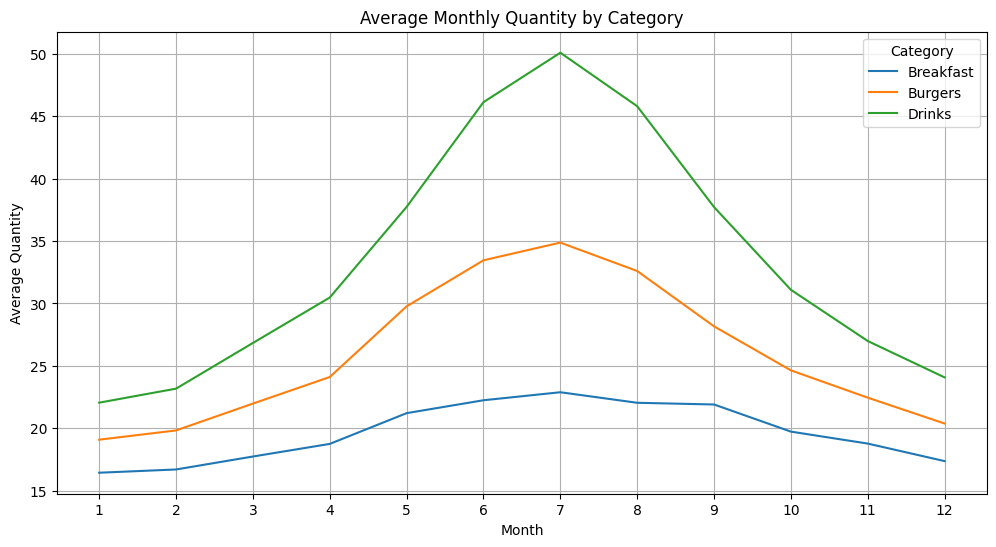

In [9]:
categories_to_plot = ['Breakfast', 'Drinks', 'Burgers']
seasonal_data = df[df['category'].isin(categories_to_plot)]

monthly_category_avg = seasonal_data.groupby(['month', 'category'])['quantity'].mean().unstack()

plt.figure(figsize=(12, 6))
monthly_category_avg.plot(kind='line', ax=plt.gca())
plt.title('Average Monthly Quantity by Category')
plt.xlabel('Month')
plt.ylabel('Average Quantity')
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend(title='Category')
plt.show()

### Year-over-Year Trend by Restaurant
Let's analyze the year-over-year sales trends for each restaurant to observe their individual growth patterns.

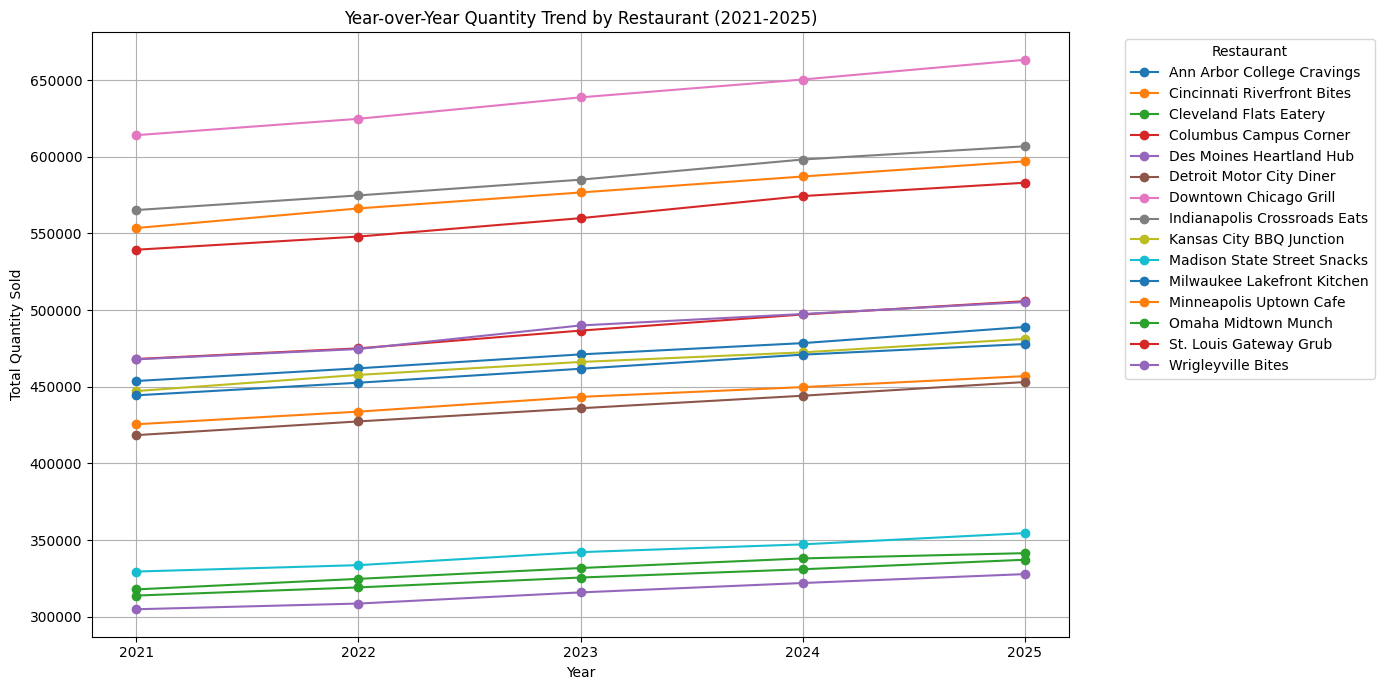

In [10]:
yearly_restaurant_sales = df.groupby(['year', 'restaurant_name'])['quantity'].sum().unstack()

plt.figure(figsize=(14, 7))
yearly_restaurant_sales.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Year-over-Year Quantity Trend by Restaurant (2021-2025)')
plt.xlabel('Year')
plt.ylabel('Total Quantity Sold')
plt.xticks(range(df['year'].min(), df['year'].max() + 1))
plt.grid(True)
plt.legend(title='Restaurant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Holiday Sales Analysis
Let's analyze how different holidays impact sales, distinguishing between holidays that boost sales versus those that might suppress them.

/var/folders/sm/rjvgx54d0k9106rww1_hb_vc0000gn/T/ipykernel_59905/2731160450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_sales.index, y=holiday_sales.values, palette='plasma')


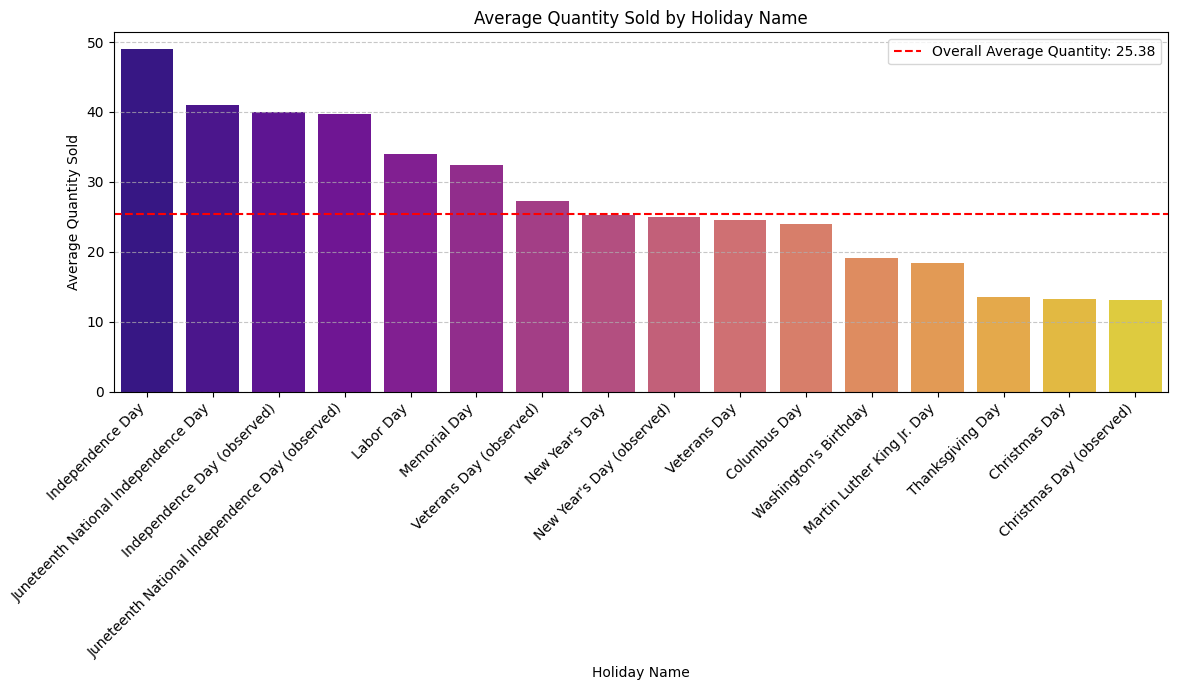

In [11]:
holiday_sales = df[df['is_holiday'] == 1].groupby('holiday_name')['quantity'].mean().sort_values(ascending=False)
overall_avg_quantity = df['quantity'].mean()

plt.figure(figsize=(12, 7))
sns.barplot(x=holiday_sales.index, y=holiday_sales.values, palette='plasma')
plt.axhline(overall_avg_quantity, color='red', linestyle='--', label=f'Overall Average Quantity: {overall_avg_quantity:.2f}')
plt.title('Average Quantity Sold by Holiday Name')
plt.xlabel('Holiday Name')
plt.ylabel('Average Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Weekday vs. Weekend Sales Breakdown
Let's analyze the difference in average quantity sold between weekdays and weekends.

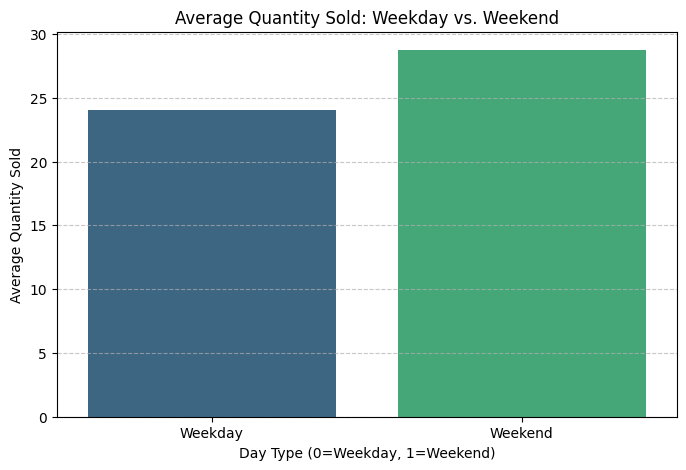

In [12]:
avg_quantity_by_day_type = df.groupby('is_weekend')['quantity'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='is_weekend', y='quantity', data=avg_quantity_by_day_type, palette='viridis', hue='is_weekend', legend=False)
plt.title('Average Quantity Sold: Weekday vs. Weekend')
plt.xlabel('Day Type (0=Weekday, 1=Weekend)')
plt.ylabel('Average Quantity Sold')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

feature signal analysis

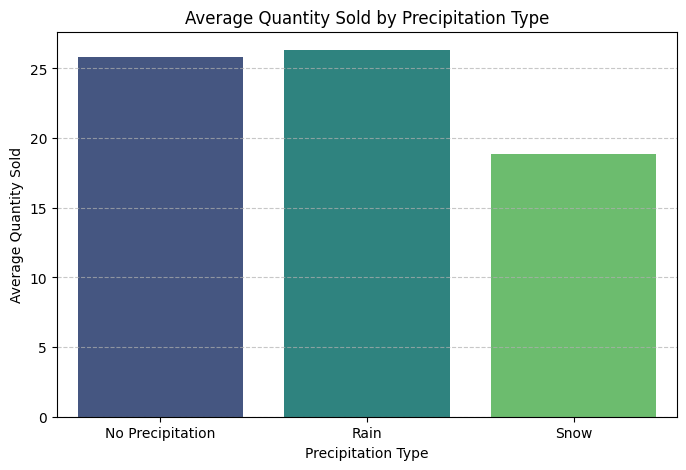

In [13]:
df_temp = df.copy()
df_temp['precip_type'] = df_temp['precip_type'].fillna('No Precipitation')

precip_effect = df_temp.groupby('precip_type')['quantity'].mean().reindex(['No Precipitation', 'Rain', 'Snow'])

plt.figure(figsize=(8, 5))
sns.barplot(x=precip_effect.index, y=precip_effect.values, palette='viridis', hue=precip_effect.index, legend=False)
plt.title('Average Quantity Sold by Precipitation Type')
plt.xlabel('Precipitation Type')
plt.ylabel('Average Quantity Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
print(df['precip_type'].value_counts(dropna=False))

precip_type
NaN     904350
Rain    348700
Snow    116450
Name: count, dtype: int64


In [15]:
# This cell was a duplicate placeholder and has been handled.

### Restaurant Sales Volume Analysis
Let's analyze the total sales volume for each restaurant to identify high and low-performing locations.

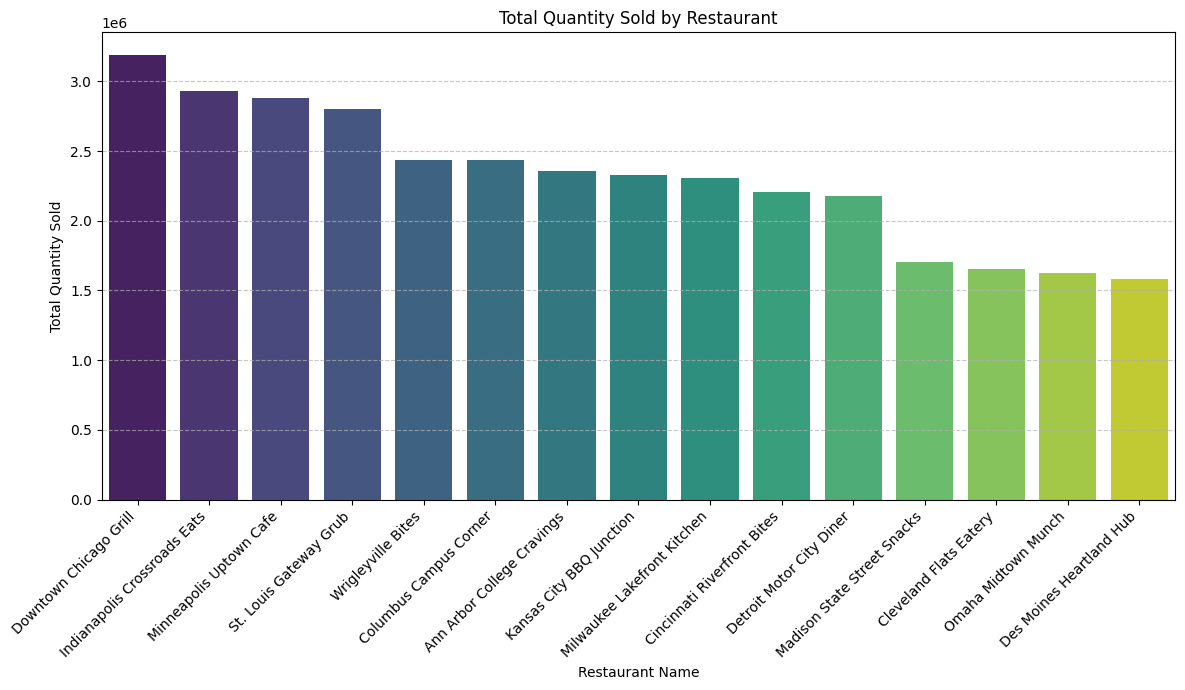


Top 5 Restaurants by Sales Volume:
restaurant_name
Downtown Chicago Grill          3191305.0
Indianapolis Crossroads Eats    2930180.0
Minneapolis Uptown Cafe         2880743.0
St. Louis Gateway Grub          2804726.0
Wrigleyville Bites              2435188.0

Bottom 5 Restaurants by Sales Volume:
restaurant_name
Detroit Motor City Diner       2179014.0
Madison State Street Snacks    1706931.0
Cleveland Flats Eatery         1653761.0
Omaha Midtown Munch            1626577.0
Des Moines Heartland Hub       1579086.0


In [16]:
restaurant_sales_volume = df.groupby('restaurant_name')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=restaurant_sales_volume.index, y=restaurant_sales_volume.values, palette='viridis', hue=restaurant_sales_volume.index, legend=False)
plt.title('Total Quantity Sold by Restaurant')
plt.xlabel('Restaurant Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 Restaurants by Sales Volume:")
print(restaurant_sales_volume.head().to_string())

print("\nBottom 5 Restaurants by Sales Volume:")
print(restaurant_sales_volume.tail().to_string())

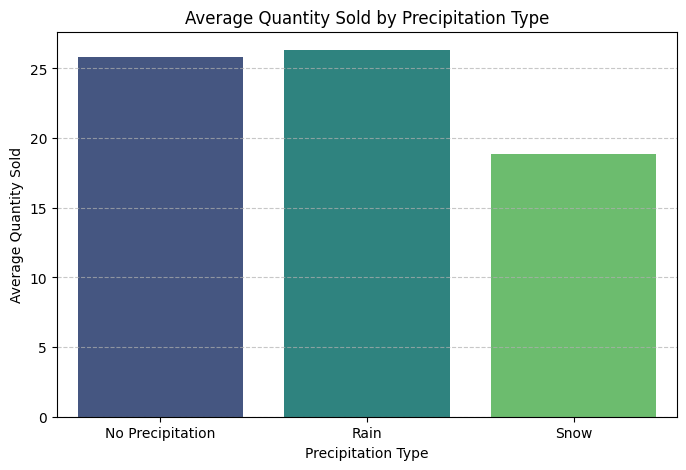

In [17]:
df_temp = df.copy()
df_temp['precip_type'] = df_temp['precip_type'].fillna('No Precipitation')

precip_effect = df_temp.groupby('precip_type')['quantity'].mean().reindex(['No Precipitation', 'Rain', 'Snow'])

plt.figure(figsize=(8, 5))
sns.barplot(x=precip_effect.index, y=precip_effect.values, palette='viridis', hue=precip_effect.index, legend=False)
plt.title('Average Quantity Sold by Precipitation Type')
plt.xlabel('Precipitation Type')
plt.ylabel('Average Quantity Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

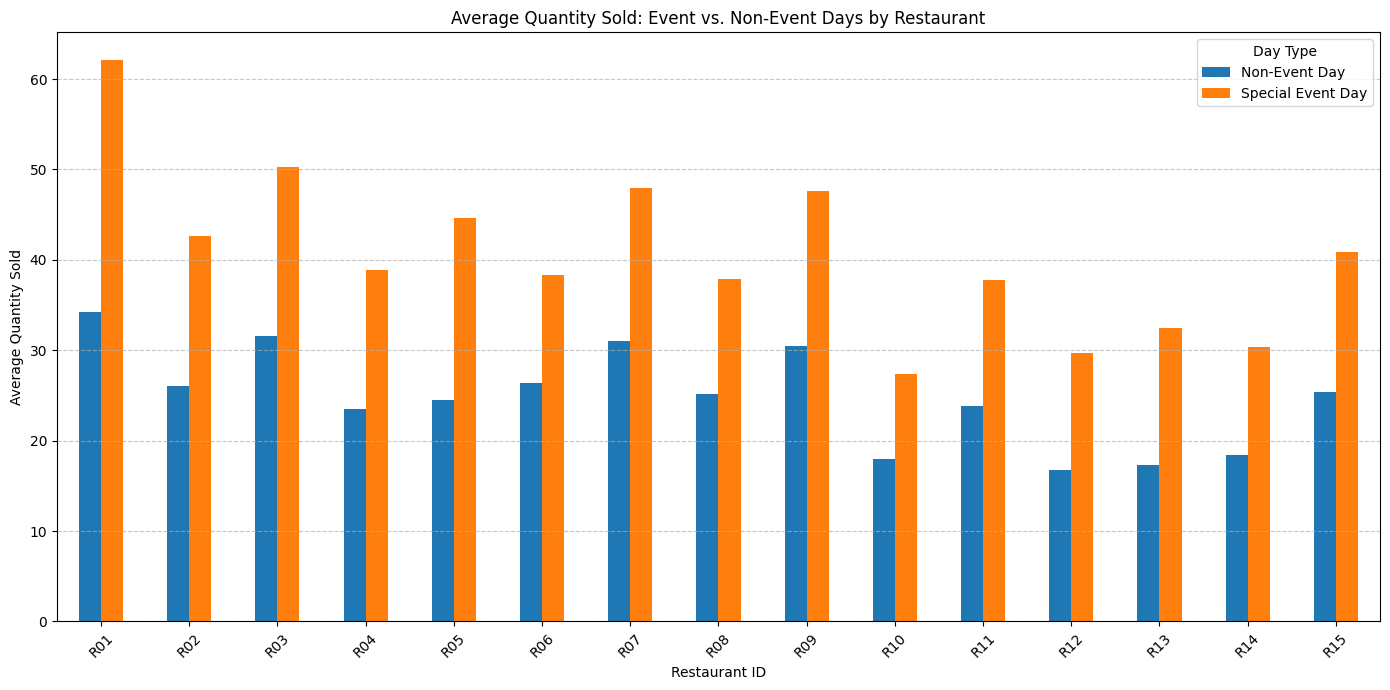

In [18]:
event_impact_by_restaurant = df.groupby(['restaurant_id', 'is_special_event'])['quantity'].mean().unstack()
event_impact_by_restaurant.columns = ['non_event_avg', 'event_avg']

plt.figure(figsize=(14, 7))
event_impact_by_restaurant.plot(kind='bar', figsize=(14, 7), rot=45, ax=plt.gca())
plt.title('Average Quantity Sold: Event vs. Non-Event Days by Restaurant')
plt.xlabel('Restaurant ID')
plt.ylabel('Average Quantity Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Day Type', labels=['Non-Event Day', 'Special Event Day'])
plt.tight_layout()
plt.show()

In [19]:
print('=' * 50)
print('Promotion Impact Analysis')
print('=' * 50)

# Overall Promotion Impact
overall_promo_impact = df.groupby('is_promotion')['quantity'].mean()
non_promo_avg = overall_promo_impact.get(0, 0)
promo_avg = overall_promo_impact.get(1, 0)

if non_promo_avg > 0:
    overall_increase_pct = ((promo_avg - non_promo_avg) / non_promo_avg) * 100
    print(f"\nOverall Average Quantity without Promotion: {non_promo_avg:.2f}")
    print(f"Overall Average Quantity with Promotion:    {promo_avg:.2f}")
    print(f"Overall Percentage Increase due to Promotions: {overall_increase_pct:.2f}%")
else:
    print("Cannot calculate overall percentage increase, no non-promotion data found.")


# Promotion Impact by Category
category_promo_impact = df.groupby(['category', 'is_promotion'])['quantity'].mean().unstack()
category_promo_impact.columns = ['non_promo_avg', 'promo_avg']

# Calculate percentage increase for each category
category_promo_impact['increase_pct'] = (
    (category_promo_impact['promo_avg'] - category_promo_impact['non_promo_avg']) /
    category_promo_impact['non_promo_avg']
) * 100

print("\nPromotion Impact by Category:")
print(category_promo_impact.round(2).to_string())


# Promotion Impact by Menu Item (Top 10 highest increases)
menu_item_promo_impact = df.groupby(['menu_item_id', 'is_promotion'])['quantity'].mean().unstack()
menu_item_promo_impact.columns = ['non_promo_avg', 'promo_avg']

# Calculate percentage increase for each menu item
menu_item_promo_impact['increase_pct'] = (
    (menu_item_promo_impact['promo_avg'] - menu_item_promo_impact['non_promo_avg']) /
    menu_item_promo_impact['non_promo_avg']
) * 100

print("\nPromotion Impact by Menu Item (Top 10 highest percentage increases):")
# Filter out NaN or inf values that might result from division by zero (no non-promo sales)
menu_item_promo_impact = menu_item_promo_impact.replace([np.inf, -np.inf], np.nan).dropna()
print(menu_item_promo_impact.nlargest(10, 'increase_pct').round(2).to_string())

Promotion Impact Analysis

Overall Average Quantity without Promotion: 25.30
Overall Average Quantity with Promotion:    31.95
Overall Percentage Increase due to Promotions: 26.29%

Promotion Impact by Category:
           non_promo_avg  promo_avg  increase_pct
category                                         
Breakfast          19.59      25.21         28.69
Burgers            25.90      32.52         25.56
Chicken            30.17      38.48         27.55
Combos             28.40      36.11         27.15
Desserts           19.29      24.91         29.12
Drinks             33.48      42.46         26.85
Sides              23.65      29.14         23.21
Specials           14.75      17.89         21.30

Promotion Impact by Menu Item (Top 10 highest percentage increases):
              non_promo_avg  promo_avg  increase_pct
menu_item_id                                        
M29                   33.90      46.20         36.29
M41                   19.98      27.01         35.21
M30   

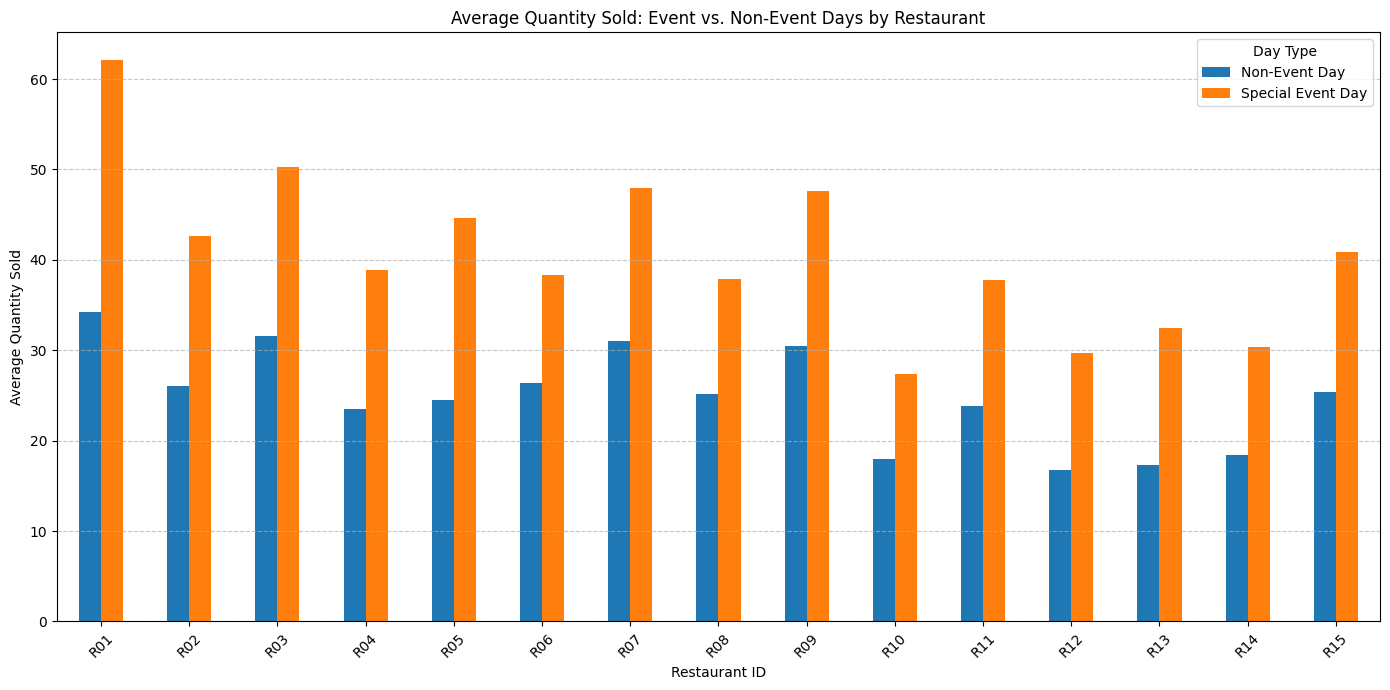

In [20]:
event_impact_by_restaurant = df.groupby(['restaurant_id', 'is_special_event'])['quantity'].mean().unstack()
event_impact_by_restaurant.columns = ['non_event_avg', 'event_avg']

plt.figure(figsize=(14, 7))
event_impact_by_restaurant.plot(kind='bar', figsize=(14, 7), rot=45, ax=plt.gca())
plt.title('Average Quantity Sold: Event vs. Non-Event Days by Restaurant')
plt.xlabel('Restaurant ID')
plt.ylabel('Average Quantity Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Day Type', labels=['Non-Event Day', 'Special Event Day'])
plt.tight_layout()
plt.show()

In [21]:
print('=' * 50)
print('Promotion Impact Analysis')
print('=' * 50)

# Overall Promotion Impact
overall_promo_impact = df.groupby('is_promotion')['quantity'].mean()
non_promo_avg = overall_promo_impact.get(0, 0)
promo_avg = overall_promo_impact.get(1, 0)

if non_promo_avg > 0:
    overall_increase_pct = ((promo_avg - non_promo_avg) / non_promo_avg) * 100
    print(f"\nOverall Average Quantity without Promotion: {non_promo_avg:.2f}")
    print(f"Overall Average Quantity with Promotion:    {promo_avg:.2f}")
    print(f"Overall Percentage Increase due to Promotions: {overall_increase_pct:.2f}%")
else:
    print("Cannot calculate overall percentage increase, no non-promotion data found.")


# Promotion Impact by Category
category_promo_impact = df.groupby(['category', 'is_promotion'])['quantity'].mean().unstack()
category_promo_impact.columns = ['non_promo_avg', 'promo_avg']

# Calculate percentage increase for each category
category_promo_impact['increase_pct'] = (
    (category_promo_impact['promo_avg'] - category_promo_impact['non_promo_avg']) /
    category_promo_impact['non_promo_avg']
) * 100

print("\nPromotion Impact by Category:")
print(category_promo_impact.round(2).to_string())


# Promotion Impact by Menu Item (Top 10 highest increases)
menu_item_promo_impact = df.groupby(['menu_item_id', 'is_promotion'])['quantity'].mean().unstack()
menu_item_promo_impact.columns = ['non_promo_avg', 'promo_avg']

# Calculate percentage increase for each menu item
menu_item_promo_impact['increase_pct'] = (
    (menu_item_promo_impact['promo_avg'] - menu_item_promo_impact['non_promo_avg']) /
    menu_item_promo_impact['non_promo_avg']
) * 100

print("\nPromotion Impact by Menu Item (Top 10 highest percentage increases):")
# Filter out NaN or inf values that might result from division by zero (no non-promo sales)
menu_item_promo_impact = menu_item_promo_impact.replace([np.inf, -np.inf], np.nan).dropna()
print(menu_item_promo_impact.nlargest(10, 'increase_pct').round(2).to_string())

Promotion Impact Analysis

Overall Average Quantity without Promotion: 25.30
Overall Average Quantity with Promotion:    31.95
Overall Percentage Increase due to Promotions: 26.29%

Promotion Impact by Category:
           non_promo_avg  promo_avg  increase_pct
category                                         
Breakfast          19.59      25.21         28.69
Burgers            25.90      32.52         25.56
Chicken            30.17      38.48         27.55
Combos             28.40      36.11         27.15
Desserts           19.29      24.91         29.12
Drinks             33.48      42.46         26.85
Sides              23.65      29.14         23.21
Specials           14.75      17.89         21.30

Promotion Impact by Menu Item (Top 10 highest percentage increases):
              non_promo_avg  promo_avg  increase_pct
menu_item_id                                        
M29                   33.90      46.20         36.29
M41                   19.98      27.01         35.21
M30   

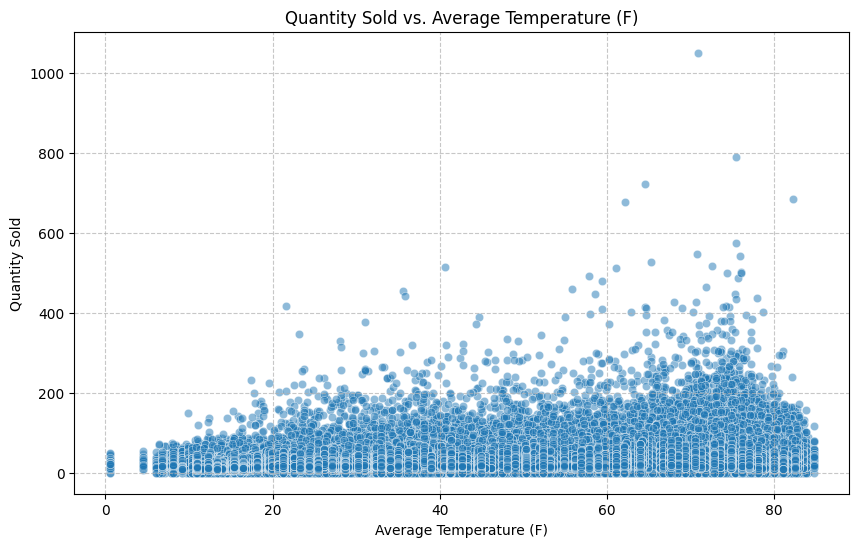

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_temp_f', y='quantity', data=df, alpha=0.5)
plt.title('Quantity Sold vs. Average Temperature (F)')
plt.xlabel('Average Temperature (F)')
plt.ylabel('Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()